<a href="https://colab.research.google.com/github/Gitau20/Data-Analysis-Ministry-Of-Health/blob/main/Gum_Scrubbing_and_Scepsis_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GUM SCRUBBING AND SCEPSIS 2022 - 2025

In [30]:
# mount dataset
# from google.colab import drive
# drive.mount('/content.drive')

In [31]:
!pip install openpyxl --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import re
from collections import Counter
import os

FILE = "/content/GUM SCRUBBING.xlsx"

FILE

'/content/GUM SCRUBBING.xlsx'

In [32]:
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

In [33]:
import pandas as pd

FILE = "/content/GUM SCRUBBING.xlsx"

dis_raw  = pd.read_excel(FILE, sheet_name="DISCHARGES", header=None)
mort_raw = pd.read_excel(FILE, sheet_name="MORTALITY", header=None)

print("DISCHARGES shape:", dis_raw.shape)
print("MORTALITY shape:", mort_raw.shape)

DISCHARGES shape: (196, 11)
MORTALITY shape: (150, 7)


# DATA CLEANING

In [34]:
# PARSE DISCHARGES
DIS_COLS = ["sno", "ip_no", "age_raw", "doa_raw", "contact", "residence", "diagnosis"]

def parse_year_blocked_sheet(raw, data_cols, year_col_idx=1, year_values=None):
    """
    Walk a raw DataFrame that uses year-marker rows to group records.
    Returns a clean DataFrame with an added 'year' column.
    """
    if year_values is None:
        year_values = {"2020", "2021", "2022", "2023", "2024", "2025"}

    records = []
    current_year = None

    for _, row in raw.iterrows():
        cell = str(row[year_col_idx]).strip()

        # Detect year-marker row
        if cell in year_values:
            current_year = int(cell)
            continue

        # Skip title / header rows
        if cell in {"IP NO", "GUM SCRUBBING CASES -MORTALITY", "DISCHARGED HOME", "nan"}:
            continue
        if str(row[0]).strip() in {"S.NO", "nan"} and cell in {"IP NO", "nan"}:
            continue

        # Skip column-header rows (contain "AGE" in the age column)
        age_cell = str(row[data_cols.index("age_raw") if "age_raw" in data_cols else 2]).strip()
        if age_cell.upper() in {"AGE", "NAN"} and cell.upper() in {"IP NO", "NAN"}:
            continue

        # Only keep rows that have at least a diagnosis or an age
        diag_idx  = 6
        age_idx   = 2
        diag_val  = str(row[diag_idx]).strip()
        age_val   = str(row[age_idx]).strip()
        if diag_val == "nan" and age_val == "nan":
            continue

        record = {"year": current_year}
        for i, col in enumerate(data_cols):
            record[col] = row[i] if i < len(row) else np.nan
        records.append(record)

    return pd.DataFrame(records)


dis = parse_year_blocked_sheet(
    dis_raw,
    data_cols=["sno", "ip_no", "age_raw", "doa_raw", "contact", "residence", "diagnosis"],
    year_col_idx=1,
    year_values={"2022", "2023", "2024", "2025"},
)

mort = parse_year_blocked_sheet(
    mort_raw,
    data_cols=["sno", "ip_no", "age_raw", "dod_raw", "residence", "contact", "diagnosis"],
    year_col_idx=1,
    year_values={"2020", "2021", "2022", "2023", "2024", "2025"},
)

print(f"Parsed DISCHARGES: {len(dis)} rows")
print(f"Parsed MORTALITY:  {len(mort)} rows")

Parsed DISCHARGES: 102 rows
Parsed MORTALITY:  130 rows


In [35]:
# CLEAN AGE COLUMN
AGE_CORRECTIONS = {
    "2yrs": "2 yrs",
    "1yr":  "1 yr",
}

def parse_age_to_months(age_str):
    """Return age in months (float). Returns NaN if unparseable."""
    if pd.isna(age_str):
        return np.nan
    s = str(age_str).lower().strip()
    for k, v in AGE_CORRECTIONS.items():
        s = s.replace(k, v)

    months = 0.0
    found  = False

    # Years component
    m = re.search(r"(\d+)\s*yr", s)
    if m:
        months += float(m.group(1)) * 12
        found = True

    # Months component
    m = re.search(r"(\d+)\s*month", s)
    if m:
        months += float(m.group(1))
        found = True

    # Weeks only (no months/years found yet)
    if not found:
        m = re.search(r"(\d+)\s*w[ke]", s)
        if m:
            months += float(m.group(1)) / 4.33
            found = True

    # Days only
    if not found:
        m = re.search(r"(\d+)\s*day", s)
        if m:
            months += float(m.group(1)) / 30.44
            found = True

    return round(months, 2) if found else np.nan


for df in [dis, mort]:
    df["age_months"] = df["age_raw"].apply(parse_age_to_months)

print("Age parsing complete.")
print("DISCHARGES — age_months sample:")
print(dis[["age_raw", "age_months"]].drop_duplicates().head(10).to_string(index=False))

Age parsing complete.
DISCHARGES — age_months sample:
      age_raw  age_months
1 yr 2 months        14.0
        2 yrs        24.0
         1 yr        12.0
     6 months         6.0
     9 months         9.0
1 yr 4 months        16.0
     8 months         8.0
     4 months         4.0
     7 months         7.0
     2 months         2.0


In [36]:
# CLEAN DATA COLUMNS
DATE_FIXES = {
    "23/22/2022": "23/02/2022",   # impossible month
    "196/02/2025": "19/02/2025",  # extra digit
    "207/12/2024": "07/12/2024",  # extra digit
    "26/11/20222": "26/11/2022",  # extra year digit
    "21/12/023":   "21/12/2023",  # short year
    "29/12/24":    "29/12/2024",  # 2-digit year
    "16/01/22":    "16/01/2022",
    "15/02/22":    "15/02/2022",
    "21/01/22":    "21/01/2022",
    "26/01/22":    "26/01/2022",
    "13/02/22":    "13/02/2022",
    "14/6/2022":   "14/06/2022",
    "30/7/2024":   "30/07/2024",
    "20/7/2025":   "20/07/2025",
    "25/062025":   "25/06/2025",  # missing slash
    "00:00:00":    np.nan,        # placeholder timestamp with no date
}

def clean_date(val):
    """Return a pd.Timestamp or NaT."""
    if pd.isna(val) or str(val).strip() in {"nan", "NaT", "", "00:00:00"}:
        return pd.NaT

    s = str(val).strip()

    # Apply manual fixes first
    if s in DATE_FIXES:
        val = DATE_FIXES[s]
        if pd.isna(val):
            return pd.NaT
        s = str(val).strip()

    # Already a datetime object from Excel parsing
    if isinstance(val, pd.Timestamp):
        return val

    # Try dd/mm/yyyy
    try:
        return pd.to_datetime(s, dayfirst=True)
    except Exception:
        pass

    # Try pandas default (will handle ISO strings)
    try:
        return pd.to_datetime(s)
    except Exception:
        return pd.NaT


dis["doa"]  = dis["doa_raw"].apply(clean_date)
mort["dod"] = mort["dod_raw"].apply(clean_date)

print("Date parsing complete.")
print(f"DISCHARGES  — DOA valid: {dis['doa'].notna().sum()} / {len(dis)}")
print(f"MORTALITY   — DOD valid: {mort['dod'].notna().sum()} / {len(mort)}")

# Flag impossible dates (year doesn't match the section year)
dis["date_year_mismatch"]  = dis.apply(
    lambda r: r["doa"].year != r["year"] if pd.notna(r["doa"]) else False, axis=1
)
mort["date_year_mismatch"] = mort.apply(
    lambda r: r["dod"].year != r["year"] if pd.notna(r["dod"]) else False, axis=1
)

print(f"\nDate-year mismatches in DISCHARGES:  {dis['date_year_mismatch'].sum()}")
print(dis[dis["date_year_mismatch"]][["year", "doa_raw", "doa"]].to_string(index=False))
print(f"\nDate-year mismatches in MORTALITY:   {mort['date_year_mismatch'].sum()}")
print(mort[mort["date_year_mismatch"]][["year", "dod_raw", "dod"]].to_string(index=False))

Date parsing complete.
DISCHARGES  — DOA valid: 102 / 102
MORTALITY   — DOD valid: 128 / 130

Date-year mismatches in DISCHARGES:  1
 year    doa_raw        doa
 2023 27/12/2025 2025-12-27

Date-year mismatches in MORTALITY:   1
 year    dod_raw        dod
 2020 29/11/2025 2025-11-29


/tmp/ipykernel_4218/75654423.py:41: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  return pd.to_datetime(s, dayfirst=True)


In [37]:
# CLEAN TEXT COLUMNS
def clean_text(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = re.sub(r"\*+$", "", s)      # remove trailing asterisks
    s = re.sub(r"\s{2,}", " ", s)   # collapse multiple spaces
    return s if s not in {"nan", ""} else np.nan


for df in [dis, mort]:
    df["diagnosis"]  = df["diagnosis"].apply(clean_text)
    df["residence"]  = df["residence"].apply(clean_text)
    df["ip_no"]      = df["ip_no"].apply(clean_text)

# Standardise residence casing
for df in [dis, mort]:
    df["residence"] = df["residence"].str.title()

print("Text cleaning done.")

Text cleaning done.


In [38]:
# Add Keyword Flags
# Binary flags for key clinical terms

KEYWORDS = {
    "septic_shock":   r"septic.?shock",
    "sepsis":         r"\bsepsis\b|\bsepticaemia\b|\bsepticemia\b",
    "dehydration":    r"dehydrat",
    "gum_scrubbing":  r"gum.?scrub",
    "sam":            r"\bsam\b",
    "meningitis":     r"meningit",
    "spna":           r"\bspna\b",
    "ge":             r"\bge\b|gastroenteritis",
    "aki":            r"\baki\b",
    "shock":          r"\bshock\b",
    "convulsion":     r"convuls|febrile.?conv",
}

for df in [dis, mort]:
    for flag, pattern in KEYWORDS.items():
        df[f"flag_{flag}"] = (
            df["diagnosis"]
            .fillna("")
            .str.lower()
            .str.contains(pattern, regex=True)
        )

print("Keyword flags added:", [f"flag_{k}" for k in KEYWORDS])


Keyword flags added: ['flag_septic_shock', 'flag_sepsis', 'flag_dehydration', 'flag_gum_scrubbing', 'flag_sam', 'flag_meningitis', 'flag_spna', 'flag_ge', 'flag_aki', 'flag_shock', 'flag_convulsion']


In [39]:
# Data Quality Summary

def quality_report(df, name, date_col):
    print(f"\n{'='*60}")
    print(f"DATA QUALITY — {name}  ({len(df)} records)")
    print(f"{'='*60}")

    miss = {
        "ip_no":      df["ip_no"].isna().sum(),
        "age_raw":    df["age_raw"].isna().sum(),
        "age_months": df["age_months"].isna().sum(),
        date_col:     df[date_col].isna().sum(),
        "residence":  df["residence"].isna().sum(),
        "diagnosis":  df["diagnosis"].isna().sum(),
    }
    for col, n in miss.items():
        pct = n / len(df) * 100
        print(f"  Missing {col:15s}: {n:3d} ({pct:.0f}%)")

    print(f"\n  Date-year mismatches : {df['date_year_mismatch'].sum()}")
    print(f"  Age range (months)   : {df['age_months'].min():.1f} – {df['age_months'].max():.1f}")


quality_report(dis,  "DISCHARGES", "doa")
quality_report(mort, "MORTALITY",  "dod")



DATA QUALITY — DISCHARGES  (102 records)
  Missing ip_no          :   0 (0%)
  Missing age_raw        :   0 (0%)
  Missing age_months     :   0 (0%)
  Missing doa            :   0 (0%)
  Missing residence      :   2 (2%)
  Missing diagnosis      :   1 (1%)

  Date-year mismatches : 1
  Age range (months)   : 1.0 – 25.0

DATA QUALITY — MORTALITY  (130 records)
  Missing ip_no          :   0 (0%)
  Missing age_raw        :   0 (0%)
  Missing age_months     :   0 (0%)
  Missing dod            :   2 (2%)
  Missing residence      : 100 (77%)
  Missing diagnosis      :   0 (0%)

  Date-year mismatches : 1
  Age range (months)   : 0.5 – 36.0


In [40]:
# EXPORT CLEANED DATA
dis.to_csv("gum_scrubbing_discharges_clean.csv",  index=False)
mort.to_csv("gum_scrubbing_mortality_clean.csv", index=False)
print("Cleaned files saved.")

Cleaned files saved.


# ANALYSIS AND VISUALIZATION

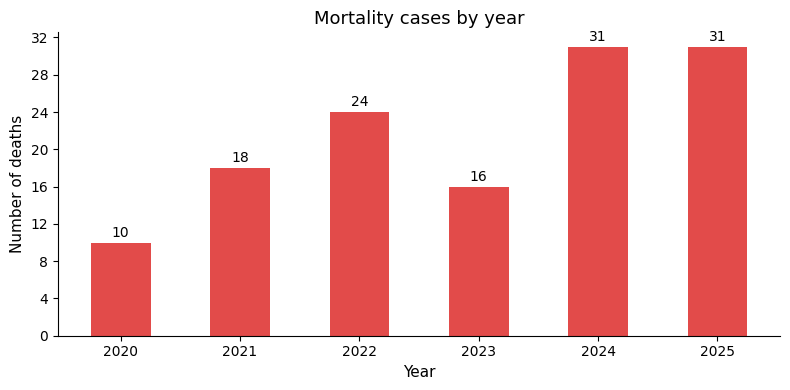

 year  deaths
 2020      10
 2021      18
 2022      24
 2023      16
 2024      31
 2025      31


In [41]:
# YEAR - TO - YEAR MORTALITY TREND

mort_by_year = mort.groupby("year").size().reset_index(name="deaths")
dis_by_year  = dis.groupby("year").size().reset_index(name="discharges")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(mort_by_year["year"], mort_by_year["deaths"], color="#E24B4A", width=0.5)
ax.set_title("Mortality cases by year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of deaths")
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
for x, y in zip(mort_by_year["year"], mort_by_year["deaths"]):
    ax.text(x, y + 0.3, str(y), ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.savefig("01_mortality_by_year.png", dpi=150)
plt.show()
print(mort_by_year.to_string(index=False))

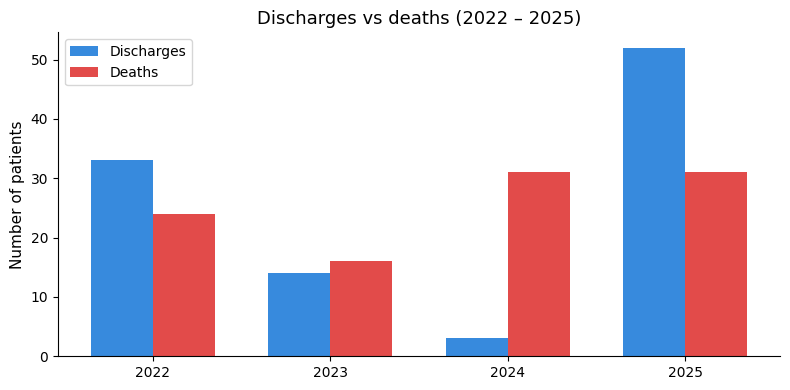

 year  discharges  deaths  cfr
 2022        33.0      24 42.1
 2023        14.0      16 53.3
 2024         3.0      31 91.2
 2025        52.0      31 37.3


In [42]:
# DISCHARGE VS MORTALITY 2022-2025

merged = dis_by_year.merge(mort_by_year, on="year", how="outer").fillna(0)
merged = merged[merged["year"] >= 2022].sort_values("year")

x      = np.arange(len(merged))
width  = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width/2, merged["discharges"], width, label="Discharges", color="#378ADD")
ax.bar(x + width/2, merged["deaths"],     width, label="Deaths",     color="#E24B4A")
ax.set_xticks(x)
ax.set_xticklabels(merged["year"].astype(int))
ax.set_title("Discharges vs deaths (2022 – 2025)")
ax.set_ylabel("Number of patients")
ax.legend()
plt.tight_layout()
plt.savefig("02_discharge_vs_mortality.png", dpi=150)
plt.show()

# Crude case-fatality rate (deaths / (deaths + discharges))
merged["cfr"] = (merged["deaths"] / (merged["deaths"] + merged["discharges"]) * 100).round(1)
print(merged[["year", "discharges", "deaths", "cfr"]].to_string(index=False))

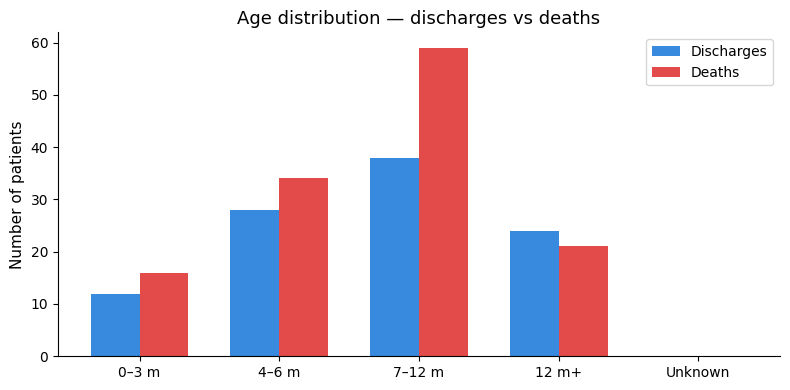

In [43]:
#AGE DISTRIBUTION
def age_bucket(months):
    if pd.isna(months):
        return "Unknown"
    if months <= 3:
        return "0–3 m"
    elif months <= 6:
        return "4–6 m"
    elif months <= 12:
        return "7–12 m"
    else:
        return "12 m+"


dis["age_bucket"]  = dis["age_months"].apply(age_bucket)
mort["age_bucket"] = mort["age_months"].apply(age_bucket)

bucket_order = ["0–3 m", "4–6 m", "7–12 m", "12 m+", "Unknown"]

dis_age  = dis["age_bucket"].value_counts().reindex(bucket_order, fill_value=0)
mort_age = mort["age_bucket"].value_counts().reindex(bucket_order, fill_value=0)

x     = np.arange(len(bucket_order))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width/2, dis_age.values,  width, label="Discharges", color="#378ADD")
ax.bar(x + width/2, mort_age.values, width, label="Deaths",     color="#E24B4A")
ax.set_xticks(x)
ax.set_xticklabels(bucket_order)
ax.set_title("Age distribution — discharges vs deaths")
ax.set_ylabel("Number of patients")
ax.legend()
plt.tight_layout()
plt.savefig("03_age_distribution.png", dpi=150)
plt.show()

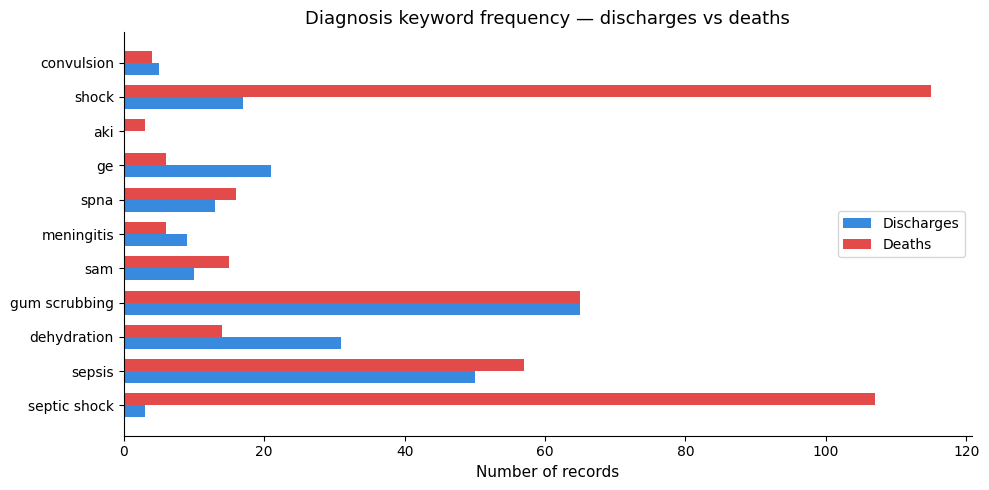

In [44]:
# KEYWORD FLAG COMPARISON

flag_cols  = [c for c in dis.columns if c.startswith("flag_")]
flag_labels = [c.replace("flag_", "").replace("_", " ") for c in flag_cols]

dis_counts  = dis[flag_cols].sum().values
mort_counts = mort[flag_cols].sum().values

x     = np.arange(len(flag_cols))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(x - width/2, dis_counts,  width, label="Discharges", color="#378ADD")
ax.barh(x + width/2, mort_counts, width, label="Deaths",     color="#E24B4A")
ax.set_yticks(x)
ax.set_yticklabels(flag_labels)
ax.set_title("Diagnosis keyword frequency — discharges vs deaths")
ax.set_xlabel("Number of records")
ax.legend()
plt.tight_layout()
plt.savefig("04_diagnosis_keywords.png", dpi=150)
plt.show()

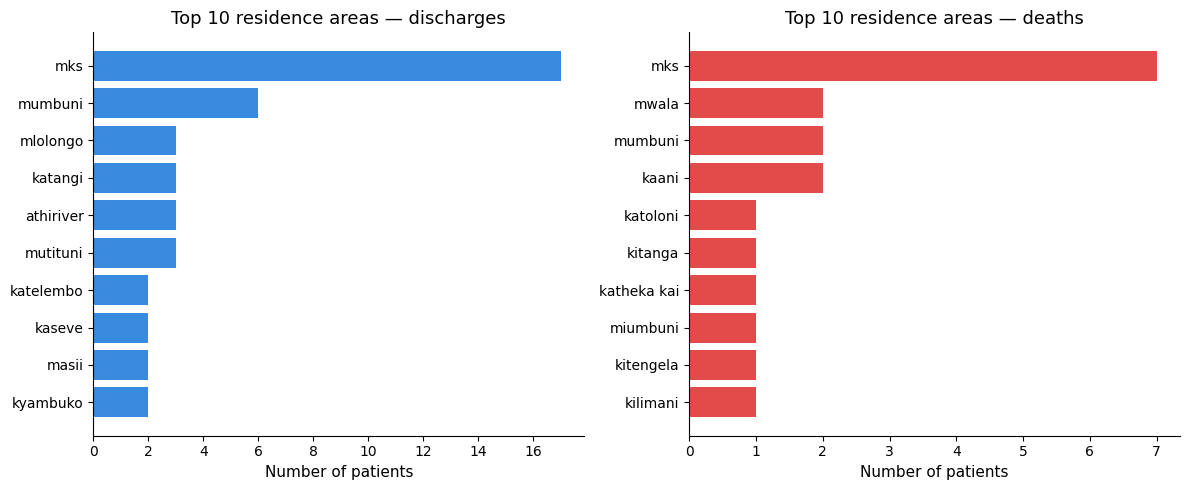

In [45]:
# TOP RESIDENT AREAS
top_n = 10

dis_res  = dis["residence"].str.lower().str.strip().value_counts().head(top_n)
mort_res = mort["residence"].str.lower().str.strip().value_counts().head(top_n)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.barh(dis_res.index[::-1],  dis_res.values[::-1],  color="#378ADD")
ax1.set_title(f"Top {top_n} residence areas — discharges")
ax1.set_xlabel("Number of patients")

ax2.barh(mort_res.index[::-1], mort_res.values[::-1], color="#E24B4A")
ax2.set_title(f"Top {top_n} residence areas — deaths")
ax2.set_xlabel("Number of patients")

plt.tight_layout()
plt.savefig("05_residence_areas.png", dpi=150)
plt.show()

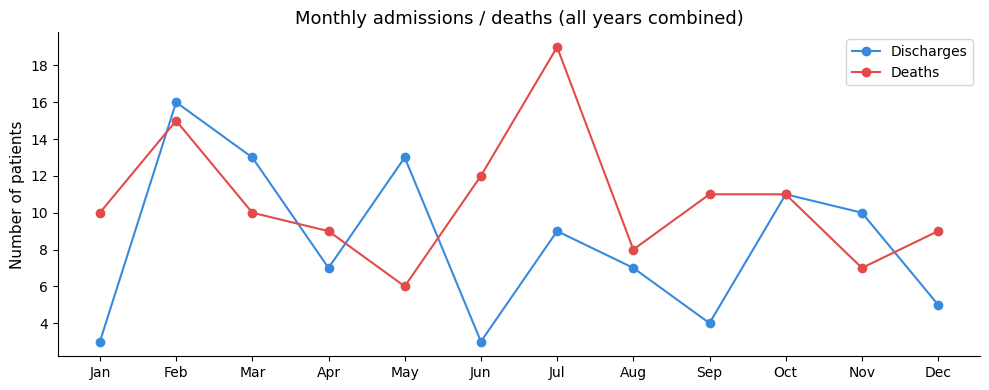

In [46]:
# MONTHLY SEASONALITY
dis_valid  = dis[dis["doa"].notna() & ~dis["date_year_mismatch"]].copy()
mort_valid = mort[mort["dod"].notna() & ~mort["date_year_mismatch"]].copy()

dis_valid["month"]  = dis_valid["doa"].dt.month
mort_valid["month"] = mort_valid["dod"].dt.month

month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

dis_month  = dis_valid["month"].value_counts().reindex(range(1, 13), fill_value=0)
mort_month = mort_valid["month"].value_counts().reindex(range(1, 13), fill_value=0)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(month_labels, dis_month.values,  marker="o", label="Discharges", color="#378ADD")
ax.plot(month_labels, mort_month.values, marker="o", label="Deaths",     color="#E24B4A")
ax.set_title("Monthly admissions / deaths (all years combined)")
ax.set_ylabel("Number of patients")
ax.legend()
plt.tight_layout()
plt.savefig("06_seasonality.png", dpi=150)
plt.show()

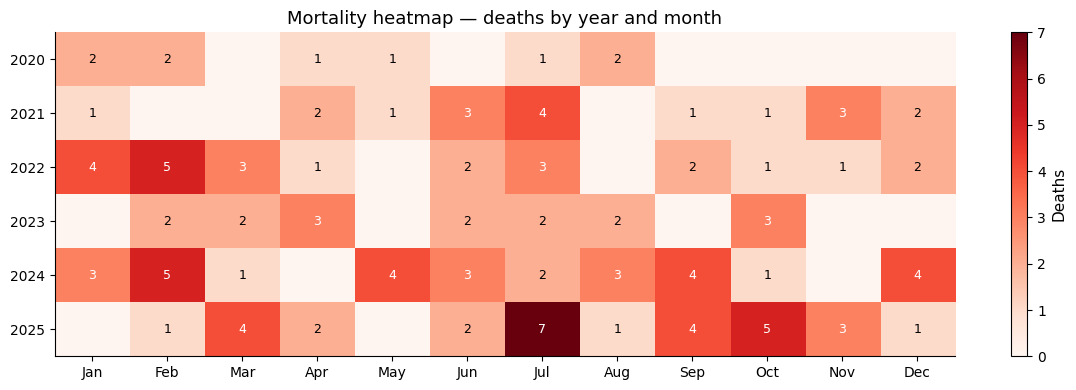

In [47]:
# MORTALITY TREND HEATMAP BY YEAR AND MONTH
pivot = (
    mort_valid.groupby(["year", "month"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=range(1, 13), fill_value=0)
)
pivot.columns = month_labels

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(pivot.values, aspect="auto", cmap="Reds")
ax.set_xticks(range(12))
ax.set_xticklabels(month_labels)
ax.set_yticks(range(len(pivot)))
ax.set_yticklabels(pivot.index.astype(int))
ax.set_title("Mortality heatmap — deaths by year and month")
plt.colorbar(im, ax=ax, label="Deaths")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        if val > 0:
            ax.text(j, i, str(val), ha="center", va="center",
                    fontsize=9, color="white" if val >= 3 else "black")
plt.tight_layout()
plt.savefig("07_mortality_heatmap.png", dpi=150)
plt.show()

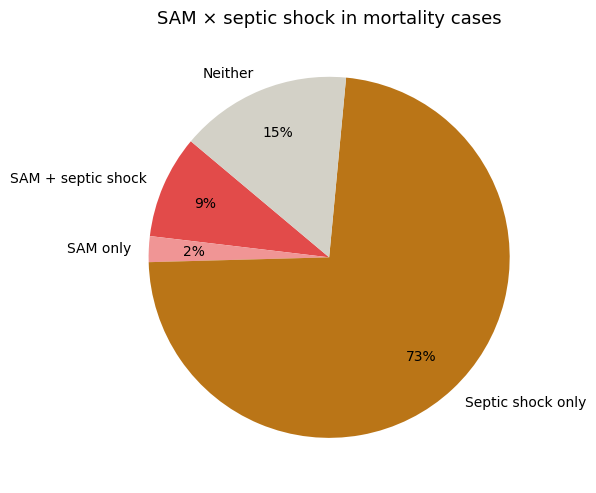

In [48]:
# SAM AS A RISK FACTOR
# Compare septic shock rate between SAM and non-SAM patients (mortality sheet).

sam_shock     = mort[mort["flag_sam"] & mort["flag_septic_shock"]].shape[0]
sam_no_shock  = mort[mort["flag_sam"] & ~mort["flag_septic_shock"]].shape[0]
nsam_shock    = mort[~mort["flag_sam"] & mort["flag_septic_shock"]].shape[0]
nsam_no_shock = mort[~mort["flag_sam"] & ~mort["flag_septic_shock"]].shape[0]

labels  = ["SAM + septic shock", "SAM only", "Septic shock only", "Neither"]
values  = [sam_shock, sam_no_shock, nsam_shock, nsam_no_shock]
colors  = ["#E24B4A", "#F09595", "#BA7517", "#D3D1C7"]

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    values, labels=labels, colors=colors,
    autopct="%1.0f%%", startangle=140, pctdistance=0.75
)
for t in autotexts:
    t.set_fontsize(10)
ax.set_title("SAM × septic shock in mortality cases")
plt.tight_layout()
plt.savefig("08_sam_risk.png", dpi=150)
plt.show()

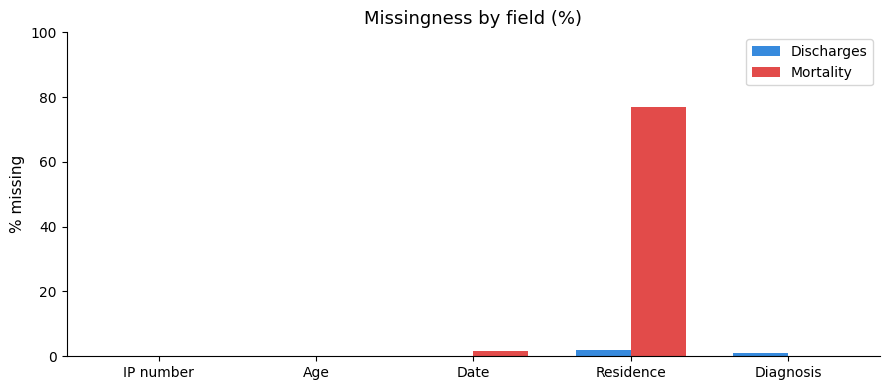

In [49]:
# DATA QUALITY VISUAL
datasets    = ["Discharges", "Mortality"]
fields      = ["IP number", "Age", "Date", "Residence", "Diagnosis"]
dis_miss    = [
    dis["ip_no"].isna().mean(),
    dis["age_months"].isna().mean(),
    dis["doa"].isna().mean(),
    dis["residence"].isna().mean(),
    dis["diagnosis"].isna().mean(),
]
mort_miss   = [
    mort["ip_no"].isna().mean(),
    mort["age_months"].isna().mean(),
    mort["dod"].isna().mean(),
    mort["residence"].isna().mean(),
    mort["diagnosis"].isna().mean(),
]

x     = np.arange(len(fields))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - width/2, [v*100 for v in dis_miss],  width, label="Discharges", color="#378ADD")
ax.bar(x + width/2, [v*100 for v in mort_miss], width, label="Mortality",  color="#E24B4A")
ax.set_xticks(x)
ax.set_xticklabels(fields)
ax.set_title("Missingness by field (%)")
ax.set_ylabel("% missing")
ax.set_ylim(0, 100)
ax.legend()
plt.tight_layout()
plt.savefig("09_data_quality.png", dpi=150)
plt.show()

In [50]:
# SUMMARY PRINT
print("=" * 55)
print("SUMMARY")
print("=" * 55)
print(f"Total discharge records  : {len(dis)}")
print(f"Total mortality records  : {len(mort)}")
print()
print("Mortality by year:")
print(mort_by_year.to_string(index=False))
print()
print("Crude case-fatality rate (2022-2025):")
print(merged[["year", "discharges", "deaths", "cfr"]].to_string(index=False))
print()
print("Median age (months):")
print(f"  Discharges : {dis['age_months'].median():.1f}")
print(f"  Mortality  : {mort['age_months'].median():.1f}")
print()
print("Most common residence (discharges):", dis["residence"].str.lower().mode()[0])
print("Most common residence (mortality) :", mort["residence"].str.lower().mode()[0])


SUMMARY
Total discharge records  : 102
Total mortality records  : 130

Mortality by year:
 year  deaths
 2020      10
 2021      18
 2022      24
 2023      16
 2024      31
 2025      31

Crude case-fatality rate (2022-2025):
 year  discharges  deaths  cfr
 2022        33.0      24 42.1
 2023        14.0      16 53.3
 2024         3.0      31 91.2
 2025        52.0      31 37.3

Median age (months):
  Discharges : 8.0
  Mortality  : 7.0

Most common residence (discharges): mks
Most common residence (mortality) : mks


# Summary

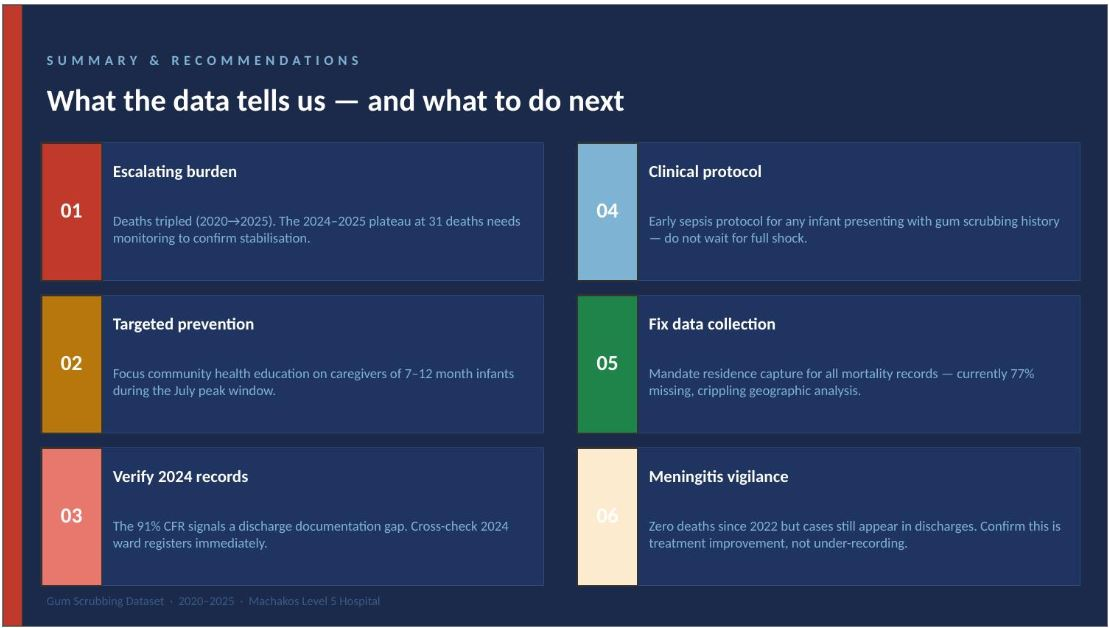

In [51]:
from PIL import Image
import matplotlib.pyplot as plt
Insights = Image.open("/content/Capture.2.JPG")
Insights